### Health Insurance Cost Prediction Model - Manual Preprocessing

In [4]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
data = pd.read_csv('insurance.csv')

In [6]:
data.head()

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,1,39.0,male,23.2,91,Yes,0,No,southeast,1121.87
1,2,24.0,male,30.1,87,No,0,No,southeast,1131.51
2,3,NaN,male,33.3,82,Yes,0,No,southeast,1135.94
3,4,NaN,male,33.7,80,No,0,No,northwest,1136.40
4,5,NaN,male,34.1,100,No,0,No,northwest,1137.01


In [7]:
data.shape

(1340, 10)

In [8]:
data.describe()

,Id,age,bmi,bloodpressure,children,claim
count,1340.000000,1335.000000,1340.000000,1340.000000,1340.000000,1340.000000
mean,670.500000,38.078652,30.668955,94.157463,1.093284,13252.745642
std,386.968991,11.102924,6.106735,11.434712,1.205334,12109.609288
min,1.000000,18.000000,16.000000,80.000000,0.000000,1121.870000
25%,335.750000,29.000000,26.275000,86.000000,0.000000,4719.685000
50%,670.500000,38.000000,30.400000,92.000000,1.000000,9369.615000
75%,1005.250000,47.000000,34.700000,99.000000,2.000000,16604.305000
max,1340.000000,60.000000,53.100000,140.000000,5.000000,63770.430000


In [9]:
data.isnull().mean()*100

Id               0.000000
age              0.373134
gender           0.000000
bmi              0.000000
bloodpressure    0.000000
diabetic         0.000000
children         0.000000
smoker           0.000000
region           0.223881
claim            0.000000
dtype: float64

In [10]:
data.dropna(inplace=True)

In [11]:
data.duplicated().sum()

0

In [12]:
numerical_cols = ['age','bmi','bloodpressure','children','claim']

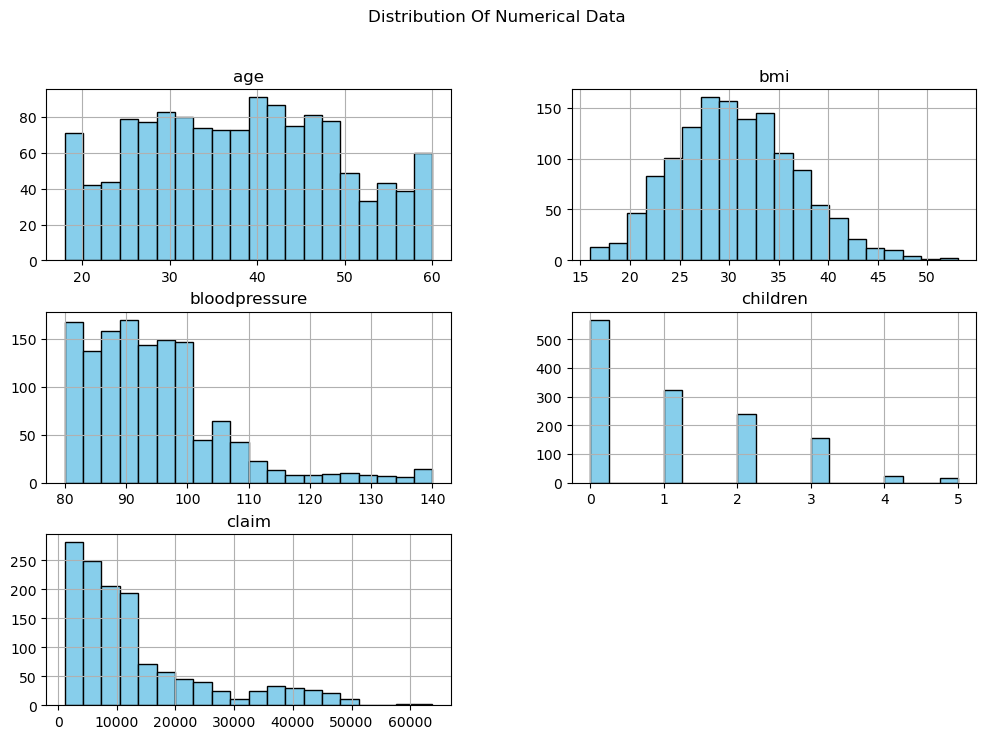

In [13]:
data[numerical_cols].hist(bins=20,figsize=(12,8),color='skyblue',edgecolor='black')
plt.suptitle("Distribution Of Numerical Data")
plt.show()

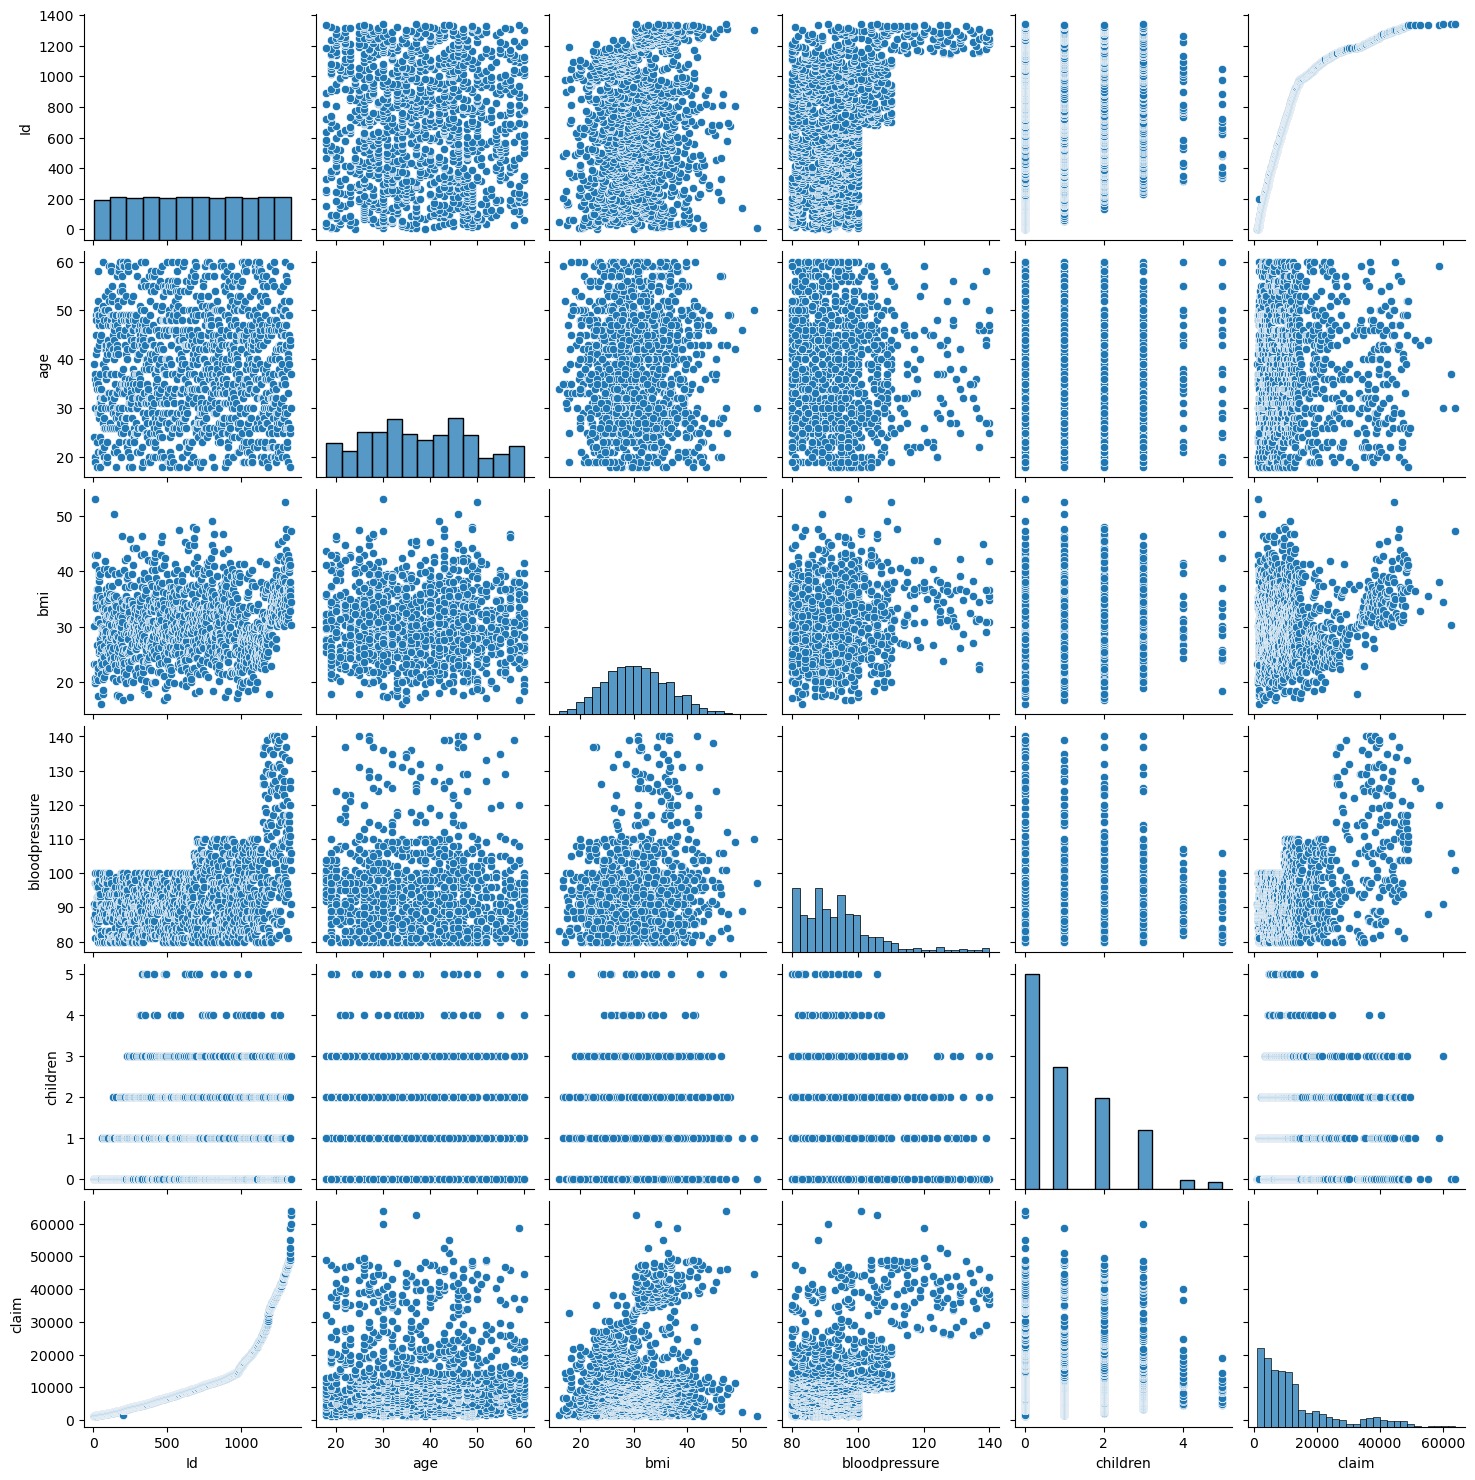

In [14]:
sns.pairplot(data)

In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1332 entries, 0 to 1339
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1332 non-null   int64  
 1   age            1332 non-null   float64
 2   gender         1332 non-null   object 
 3   bmi            1332 non-null   float64
 4   bloodpressure  1332 non-null   int64  
 5   diabetic       1332 non-null   object 
 6   children       1332 non-null   int64  
 7   smoker         1332 non-null   object 
 8   region         1332 non-null   object 
 9   claim          1332 non-null   float64
dtypes: float64(3), int64(3), object(4)
memory usage: 114.5+ KB


### Feature Engineering 
- genter - Onehotencoding
- diabetic - Onehotencoding
- smoker - Onehotencoding
- region - Onehotending


In [16]:
data.drop(columns='Id',inplace=True)

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [18]:
X_train,X_test,y_train,y_test = train_test_split(data.drop(columns='claim'),data['claim'],test_size=0.2,random_state=42)

In [19]:
print(X_train.shape,X_test.shape)
print(y_train.shape,y_test.shape)

(1065, 8) (267, 8)
(1065,) (267,)


In [20]:
X_train

,age,gender,bmi,bloodpressure,diabetic,children,smoker,region
1287,32.0,female,39.0,96,Yes,0,Yes,northwest
593,41.0,female,31.1,93,No,0,No,southeast
972,47.0,female,23.1,92,No,0,No,northeast
428,34.0,female,30.7,90,No,1,No,southeast
178,60.0,female,32.1,98,No,2,No,southeast
...,...,...,...,...,...,...,...,...
1103,36.0,male,23.2,80,Yes,1,Yes,southeast
1138,20.0,male,28.2,107,Yes,3,Yes,northwest
1302,35.0,female,32.5,134,Yes,0,Yes,southeast
868,44.0,male,27.5,104,Yes,1,No,southwest


In [21]:
preprocessing = ColumnTransformer(
    transformers=[
        ('OneHotEncoder',OneHotEncoder(drop='first',handle_unknown='ignore',sparse_output=False),[1,4,6,7])
    ],remainder='passthrough'
)

In [22]:
model1 = LinearRegression()

In [23]:
pipe1 = Pipeline(
    steps=[
        ('preprocessing',preprocessing),
        ('model',model1)
    ]
)

In [24]:
pipe1.fit(X_train,y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('OneHotEncoder',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  [1, 4, 6, 7])])),
                ('model', LinearRegression())])

In [25]:
y_pred1=pipe1.predict(X_test)

In [26]:
print("R2_score of Linear Regression = ",r2_score(y_test,y_pred1)*100)

R2_score of Linear Regression =  73.03130998448943


In [27]:
model2 = DecisionTreeRegressor(max_depth=8,random_state=42)

In [28]:
pipe2 = Pipeline(steps=[
    ('preprocessing',preprocessing),
    ('model2',model2)
])

In [29]:
pipe2.fit(X_train,y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('OneHotEncoder',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  [1, 4, 6, 7])])),
                ('model2',
                 DecisionTreeRegressor(max_depth=8, random_state=42))])

In [30]:
y_pred2 = pipe2.predict(X_test)

In [31]:
print("R2_score of Decision Tree = ",r2_score(y_test,y_pred2))

R2_score of Decision Tree =  0.7960451286825064


In [32]:
model3 = RandomForestRegressor(
    n_estimators=700,
    criterion='absolute_error',
    random_state=42,
    n_jobs=-1,
    max_depth=15
    )

In [33]:
pipe3 = Pipeline(steps=[
    ('preprocessing',preprocessing),
    ('model3',model3)
])

In [34]:
pipe3.fit(X_train,y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('OneHotEncoder',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  [1, 4, 6, 7])])),
                ('model3',
                 RandomForestRegressor(criterion='absolute_error', max_depth=15,
                                       n_estimators=700, n_jobs=-1,
                                       random_state=42))])

In [35]:
y_pred3 = pipe3.predict(X_test)

In [36]:
print("R2_score of RandomForest = ",r2_score(y_test,y_pred3)*100)

R2_score of RandomForest =  81.55616253815607


In [37]:
model4 = GradientBoostingRegressor(
    n_estimators=500,
    criterion='squared_error',
    max_depth=10,
    random_state=42
)

In [38]:
pipe4 = Pipeline(steps=[
    ('preprocessing',preprocessing),
    ('modle4',model4)
])

In [39]:
pipe4.fit(X_train,y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('OneHotEncoder',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  [1, 4, 6, 7])])),
                ('modle4',
                 GradientBoostingRegressor(criterion='squared_error',
                                           max_depth=10, n_estimators=500,
                                           random_state=42))])

In [40]:
y_pred4 = pipe4.predict(X_test)

In [41]:
print("R2_Score of GradientBoost = ",r2_score(y_test,y_pred4))

R2_Score of GradientBoost =  0.7786108620833709


In [42]:
import joblib

In [44]:
joblib.dump(pipe3,"model.pkl")

['model.pkl']